In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/stars.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.3+ KB


In [6]:
df = df.rename(columns={
    'Temperature (K)': 'temperature',
    'Luminosity(L/Lo)': 'luminosity',
    'Radius(R/Ro)': 'radius',
    'Absolute magnitude(Mv)': 'magnitude',
    'Star type': 'type',
    'Star color': 'color',
    'Spectral Class': 'spectralClass'
})

In [12]:
df["color"].unique()

array(['Red', 'Blue White', 'White', 'Yellowish White', 'Blue white',
       'Pale yellow orange', 'Blue', 'Blue-white', 'Whitish',
       'yellow-white', 'Orange', 'White-Yellow', 'white', 'Blue ',
       'yellowish', 'Yellowish', 'Orange-Red', 'Blue white ',
       'Blue-White'], dtype=object)

In [13]:
df["spectralClass"].unique()

array(['M', 'B', 'A', 'F', 'O', 'K', 'G'], dtype=object)

In [14]:
from sklearn.preprocessing import LabelEncoder

In [16]:
le_color = LabelEncoder()
df["color"] = le_color.fit_transform(df["color"])


In [17]:
le_spectral = LabelEncoder()
df["spectralClass"] = le_spectral.fit_transform(df["spectralClass"])


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    240 non-null    int64  
 1   luminosity     240 non-null    float64
 2   radius         240 non-null    float64
 3   magnitude      240 non-null    float64
 4   type           240 non-null    int64  
 5   color          240 non-null    int32  
 6   spectralClass  240 non-null    int32  
dtypes: float64(3), int32(2), int64(2)
memory usage: 11.4 KB


In [19]:
df.head()

,temperature,luminosity,radius,magnitude,type,color,spectralClass
0,3068,0.002400,0.1700,16.12,0,10,5
1,3042,0.000500,0.1542,16.60,0,10,5
2,2600,0.000300,0.1020,18.70,0,10,5
3,2800,0.000200,0.1600,16.65,0,10,5
4,1939,0.000138,0.1030,20.06,0,10,5


In [20]:
df["spectralClass"].unique()

array([5, 1, 0, 2, 6, 4, 3])

In [21]:
df["color"].unique()

array([10,  2, 11, 15,  3,  9,  0,  6, 13, 17,  7, 12, 16,  1, 18, 14,  8,
        4,  5])

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
num_features = ['temperature', 'luminosity', 'radius', 'magnitude']

In [39]:
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

In [40]:
df.head()

,temperature,luminosity,radius,magnitude,type,color,spectralClass
0,-0.779382,-0.598624,-0.459210,1.116745,0,10,5
1,-0.782110,-0.598624,-0.459241,1.162414,0,10,5
2,-0.828477,-0.598624,-0.459342,1.362213,0,10,5
3,-0.807496,-0.598624,-0.459229,1.167171,0,10,5
4,-0.897819,-0.598624,-0.459340,1.491607,0,10,5


### Görselleştirme

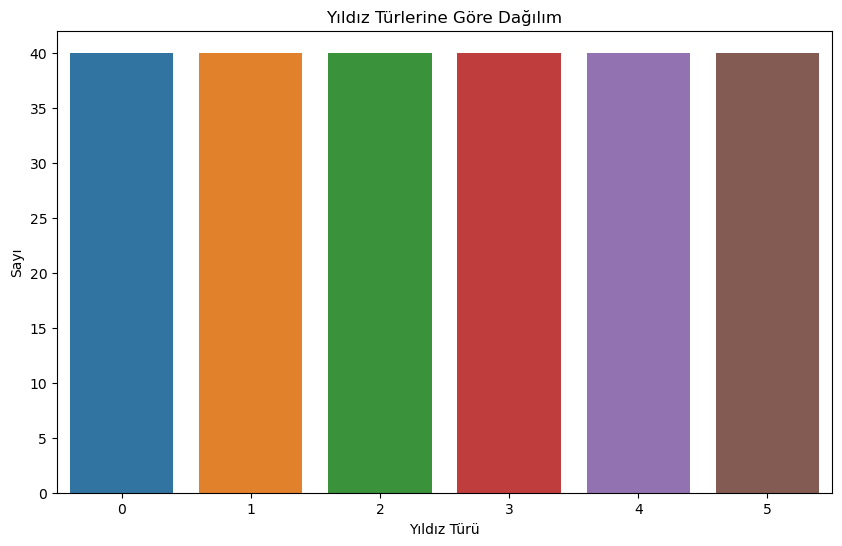

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='type')
plt.title('Yıldız Türlerine Göre Dağılım')
plt.xlabel('Yıldız Türü')
plt.ylabel('Sayı')
plt.show()

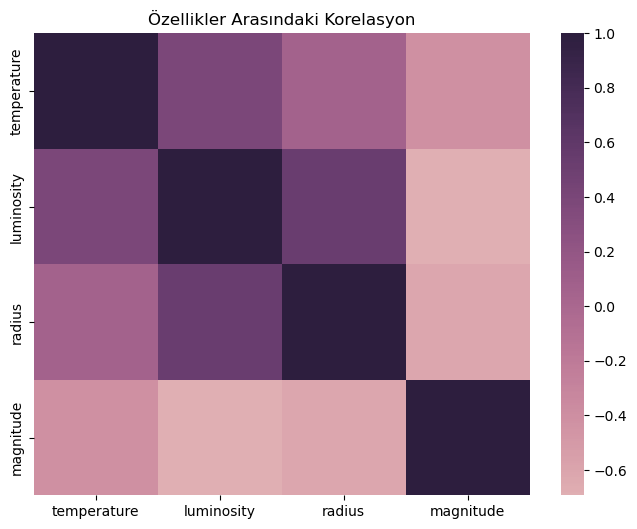

In [29]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[['temperature', 'luminosity', 'radius', 'magnitude']].corr()
sns.heatmap(correlation_matrix, annot=False, cmap=sns.cubehelix_palette(as_cmap=True), center=0)
plt.title('Özellikler Arasındaki Korelasyon')
plt.show()

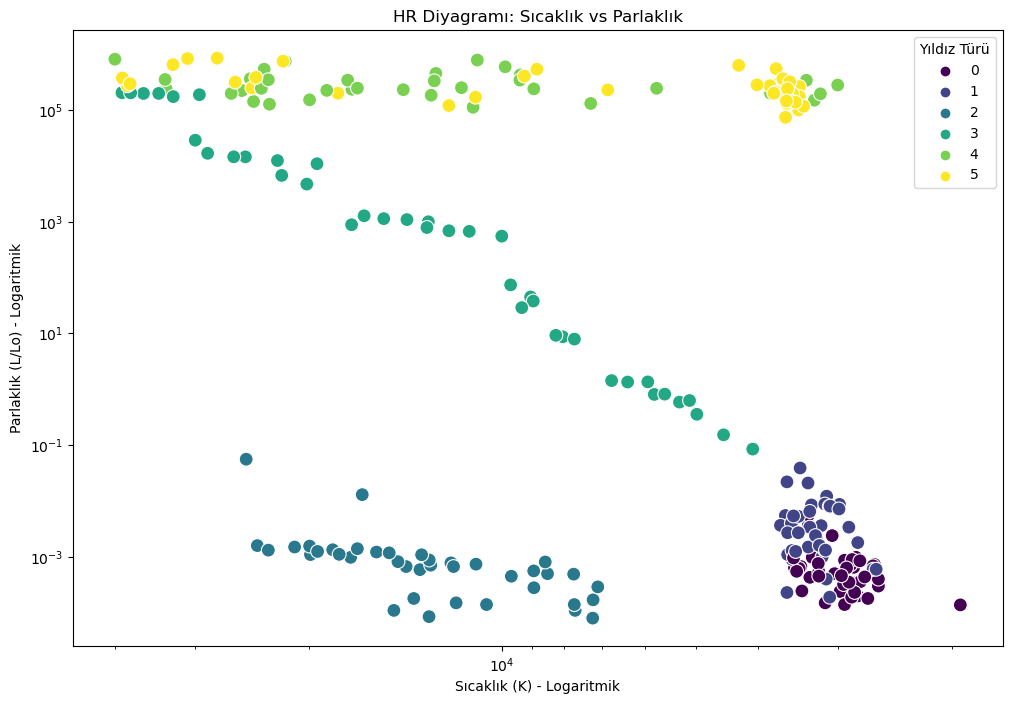

In [31]:
#  Hertzsprung-Russell Diagram
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='temperature', y='luminosity', hue='type', palette='viridis', s=100)
plt.xscale('log')
plt.yscale('log')
plt.gca().invert_xaxis()  # Sıcaklık ters yönde (astronomi standardı)
plt.title('HR Diyagramı: Sıcaklık vs Parlaklık')
plt.xlabel('Sıcaklık (K) - Logaritmik')
plt.ylabel('Parlaklık (L/Lo) - Logaritmik')
plt.legend(title='Yıldız Türü')
plt.show()

c:\Users\ackrb\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ackrb\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ackrb\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\ackrb\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

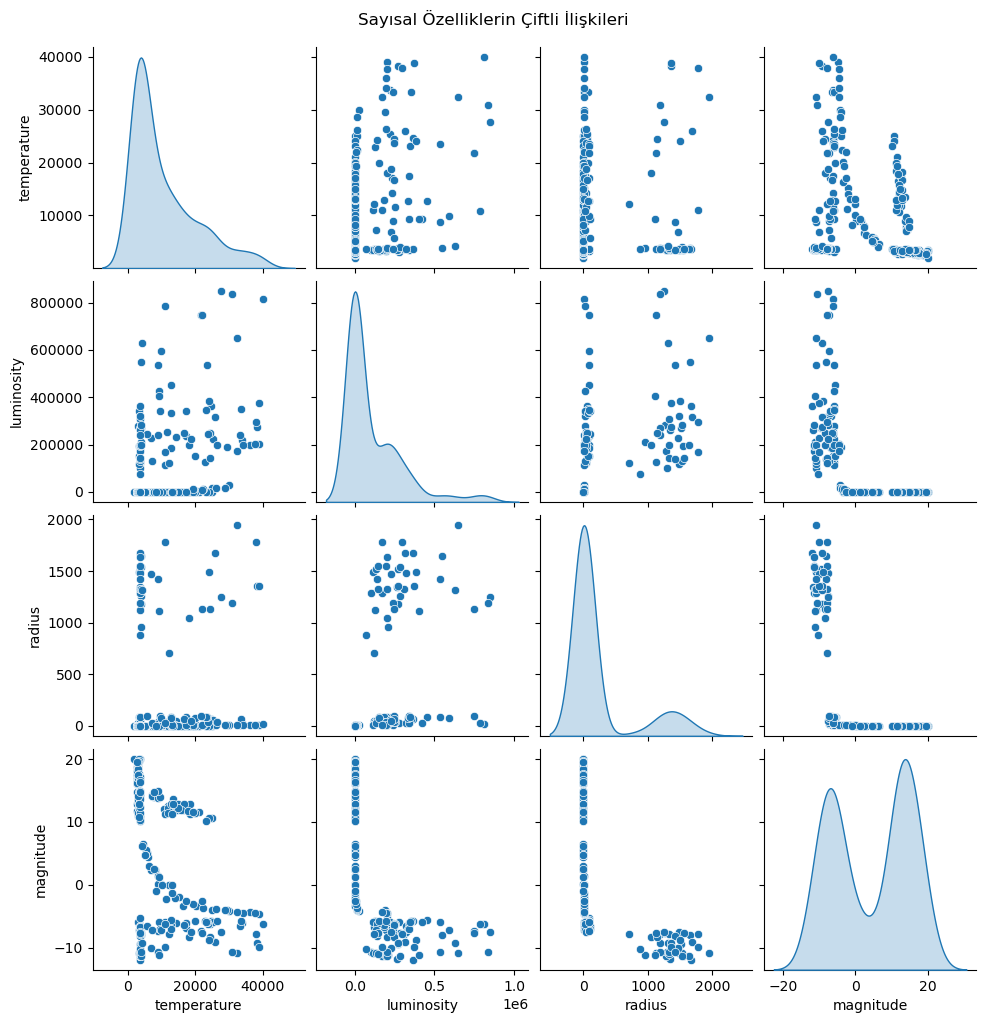

In [36]:
numerical_features = ['temperature', 'luminosity', 'radius', 'magnitude']
sns.pairplot(df[numerical_features], diag_kind='kde')
plt.suptitle('Sayısal Özelliklerin Çiftli İlişkileri', y=1.02)
plt.show()